# YOLO SFP Prediction Viewer

Visualize SFP port-pair pose model predictions from saved dataset images or live ROS camera topics.

In [1]:
from pathlib import Path
import math
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO


def find_ws_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "src" / "ais").exists() and (path / "data").exists():
            return path
        if (path / "pixi.toml").exists() and (path / "ais").exists():
            return path.parent
        nested = path / "ws_aic"
        if (nested / "src" / "ais").exists() and (nested / "data").exists():
            return nested
    raise RuntimeError("Could not find ws_aic root from current working directory.")


WS_ROOT = find_ws_root(Path.cwd().resolve())
TARGET = "SFP"
MODEL_PATH = WS_ROOT / "model" / "ais_yolo" / "approach" / TARGET / "weights" / "best.pt"
DATASET_DIR = WS_ROOT / "data" / "yolo" / "approach" / TARGET

CAMERAS = ["left", "center", "right"]
CLASS_NAMES = {0: "port_pair" if TARGET == "SFP" else "sc_port"}
KEYPOINT_NAMES = [
    "port0_top_left",
    "port0_top_right",
    "port0_bottom_right",
    "port0_bottom_left",
    "port1_top_left",
    "port1_top_right",
    "port1_bottom_right",
    "port1_bottom_left",
] if TARGET == "SFP" else []
IMAGE_EXTS = {".bmp", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}

CONF = 0.5
IMGSZ = 640
DEVICE = 0  # CPU: "cpu"
SHOW_KEYPOINT_NAMES = False

print(f"WS_ROOT: {WS_ROOT}")
print(f"TARGET: {TARGET}")
print(f"MODEL_PATH: {MODEL_PATH} exists={MODEL_PATH.exists()}")
print(f"DATASET_DIR: {DATASET_DIR} exists={DATASET_DIR.exists()}")

WS_ROOT: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic
TARGET: SFP
MODEL_PATH: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/model/ais_yolo/approach/SFP/weights/best.pt exists=True
DATASET_DIR: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/yolo/approach/SFP exists=True


In [2]:
model = YOLO(str(MODEL_PATH))
print(model)

YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_sta

In [3]:
BOX_COLOR = (0, 255, 0)
PORT_COLORS = [(0, 255, 255), (255, 0, 255)]


def draw_prediction(image_bgr: np.ndarray, conf: float = CONF) -> tuple[np.ndarray, int]:
    results = model(image_bgr, verbose=False, conf=conf, imgsz=IMGSZ, device=DEVICE)
    annotated = image_bgr.copy()
    detections = 0

    for result in results:
        keypoints = None
        if result.keypoints is not None:
            keypoints = result.keypoints.xy.cpu().numpy()

        for det_idx, box in enumerate(result.boxes):
            cls = int(box.cls[0])
            score = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            label = f"{CLASS_NAMES.get(cls, 'unknown')} {score:.2f}"

            cv2.rectangle(annotated, (x1, y1), (x2, y2), BOX_COLOR, 2)
            cv2.putText(
                annotated,
                label,
                (x1 + 2, max(20, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                BOX_COLOR,
                2,
            )

            if keypoints is not None and det_idx < len(keypoints):
                pts = keypoints[det_idx]
                for port_idx, start in enumerate([0, 4]):
                    color = PORT_COLORS[port_idx]
                    port_pts = pts[start:start + 4].astype(int)
                    cv2.polylines(annotated, [port_pts], isClosed=True, color=color, thickness=2)
                    for kpt_idx, (x, y) in enumerate(port_pts, start=start):
                        text = KEYPOINT_NAMES[kpt_idx] if SHOW_KEYPOINT_NAMES else str(kpt_idx)
                        cv2.circle(annotated, (int(x), int(y)), 4, color, -1)
                        cv2.putText(
                            annotated,
                            text,
                            (int(x) + 4, int(y) - 4),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.45,
                            color,
                            1,
                        )

            detections += 1

    cv2.putText(
        annotated,
        f"Detections: {detections}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2,
    )
    return annotated, detections


def show_bgr_images(items: list[tuple[str, np.ndarray]], cols: int = 3, figsize_per_image=(5.2, 4.2)) -> None:
    if not items:
        raise RuntimeError("No images to show.")
    cols = min(cols, len(items))
    rows = math.ceil(len(items) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per_image[0] * cols, figsize_per_image[1] * rows), squeeze=False)
    for ax in axes.ravel():
        ax.set_axis_off()
    for ax, (title, image_bgr) in zip(axes.ravel(), items):
        ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10)
    fig.tight_layout()


def read_image_bgr(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Could not read image: {path}")
    return image

## Predict Saved Dataset Images

/home/vsc/LLM_TUNE/structure-stability/venv/venv-stability/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


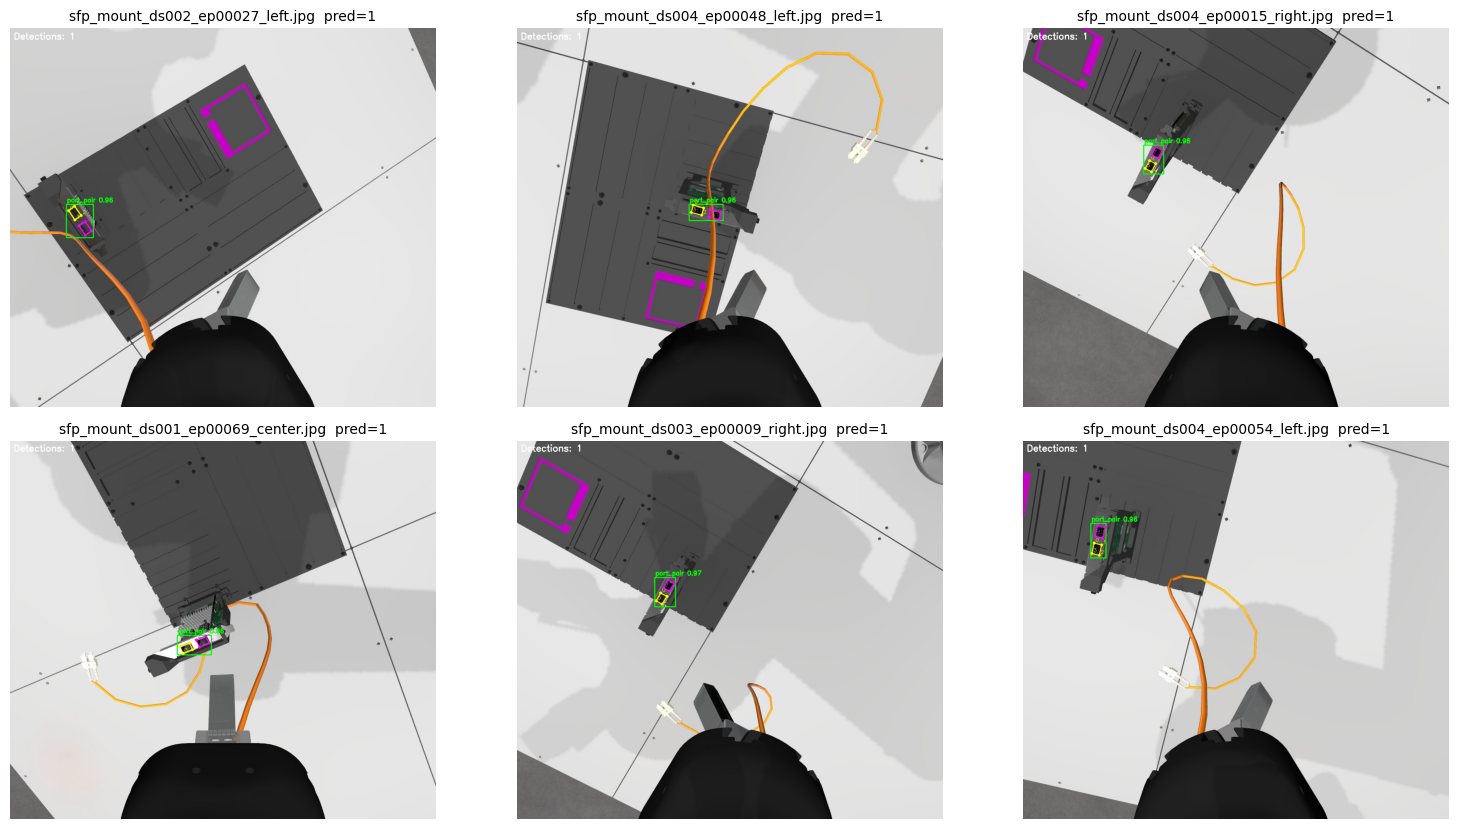

In [4]:
SPLIT = "val"       # "train" or "val"
N_SAMPLES = 6
SEED = 3
IMAGE_FILTER = ""   # e.g. "center", "left", "right", or "ep00040"


def iter_dataset_images(split: str) -> list[Path]:
    image_dir = DATASET_DIR / "images" / split
    images = sorted(p for p in image_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
    if IMAGE_FILTER:
        images = [p for p in images if IMAGE_FILTER in p.name]
    return images


images = iter_dataset_images(SPLIT)
if not images:
    raise RuntimeError(f"No images found for split={SPLIT!r} filter={IMAGE_FILTER!r}")

rng = random.Random(SEED)
samples = rng.sample(images, min(N_SAMPLES, len(images)))
annotated = []
for path in samples:
    pred, count = draw_prediction(read_image_bgr(path))
    annotated.append((f"{path.name}  pred={count}", pred))

show_bgr_images(annotated)

## Predict Live ROS Camera Snapshot

Run this when the simulator is already publishing `/left_camera/image`, `/center_camera/image`, and `/right_camera/image`.

In [5]:
def ros_image_to_bgr(msg) -> np.ndarray:
    image = np.frombuffer(msg.data, dtype=np.uint8).reshape(msg.height, msg.width, -1)
    if msg.encoding == "rgb8":
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    elif msg.encoding == "rgba8":
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2BGR)
    elif msg.encoding == "bgra8":
        image = cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
    elif msg.encoding == "mono8":
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    return image


def capture_ros_images(wait_s: float = 15.0) -> dict[str, np.ndarray]:
    import rclpy
    from rclpy.node import Node
    from sensor_msgs.msg import Image

    class CameraSnapshotNode(Node):
        def __init__(self):
            super().__init__("ais_yolo_notebook_viewer")
            self.images = {}
            for camera in CAMERAS:
                self.create_subscription(
                    Image,
                    f"/{camera}_camera/image",
                    lambda msg, name=camera: self.images.__setitem__(name, ros_image_to_bgr(msg)),
                    10,
                )

        def ready(self) -> bool:
            return len(self.images) == len(CAMERAS)

    already_initialized = rclpy.ok()
    if not already_initialized:
        rclpy.init()
    node = CameraSnapshotNode()
    try:
        start = time.time()
        while not node.ready() and time.time() - start < wait_s:
            rclpy.spin_once(node, timeout_sec=0.2)
        if not node.ready():
            missing = [name for name in CAMERAS if name not in node.images]
            raise RuntimeError(f"Camera images not ready after {wait_s:.1f}s. missing={missing}")
        return dict(node.images)
    finally:
        node.destroy_node()
        if not already_initialized:
            rclpy.shutdown()

In [6]:
# Execute this cell after the simulator is running.
ros_images = capture_ros_images(wait_s=15.0)
annotated = []
for camera in CAMERAS:
    pred, count = draw_prediction(ros_images[camera])
    annotated.append((f"{camera}  pred={count}", pred))

show_bgr_images(annotated)

ModuleNotFoundError: No module named 'rclpy'